# Using pretrained models

The Model Hub makes selecting the appropriate model simple, so that using it in any downstream library can be done in a few lines of code. Let’s take a look at how to actually use one of these models, and how to contribute back to the community.

Let’s say we’re looking for a French-based model that can perform mask filling.

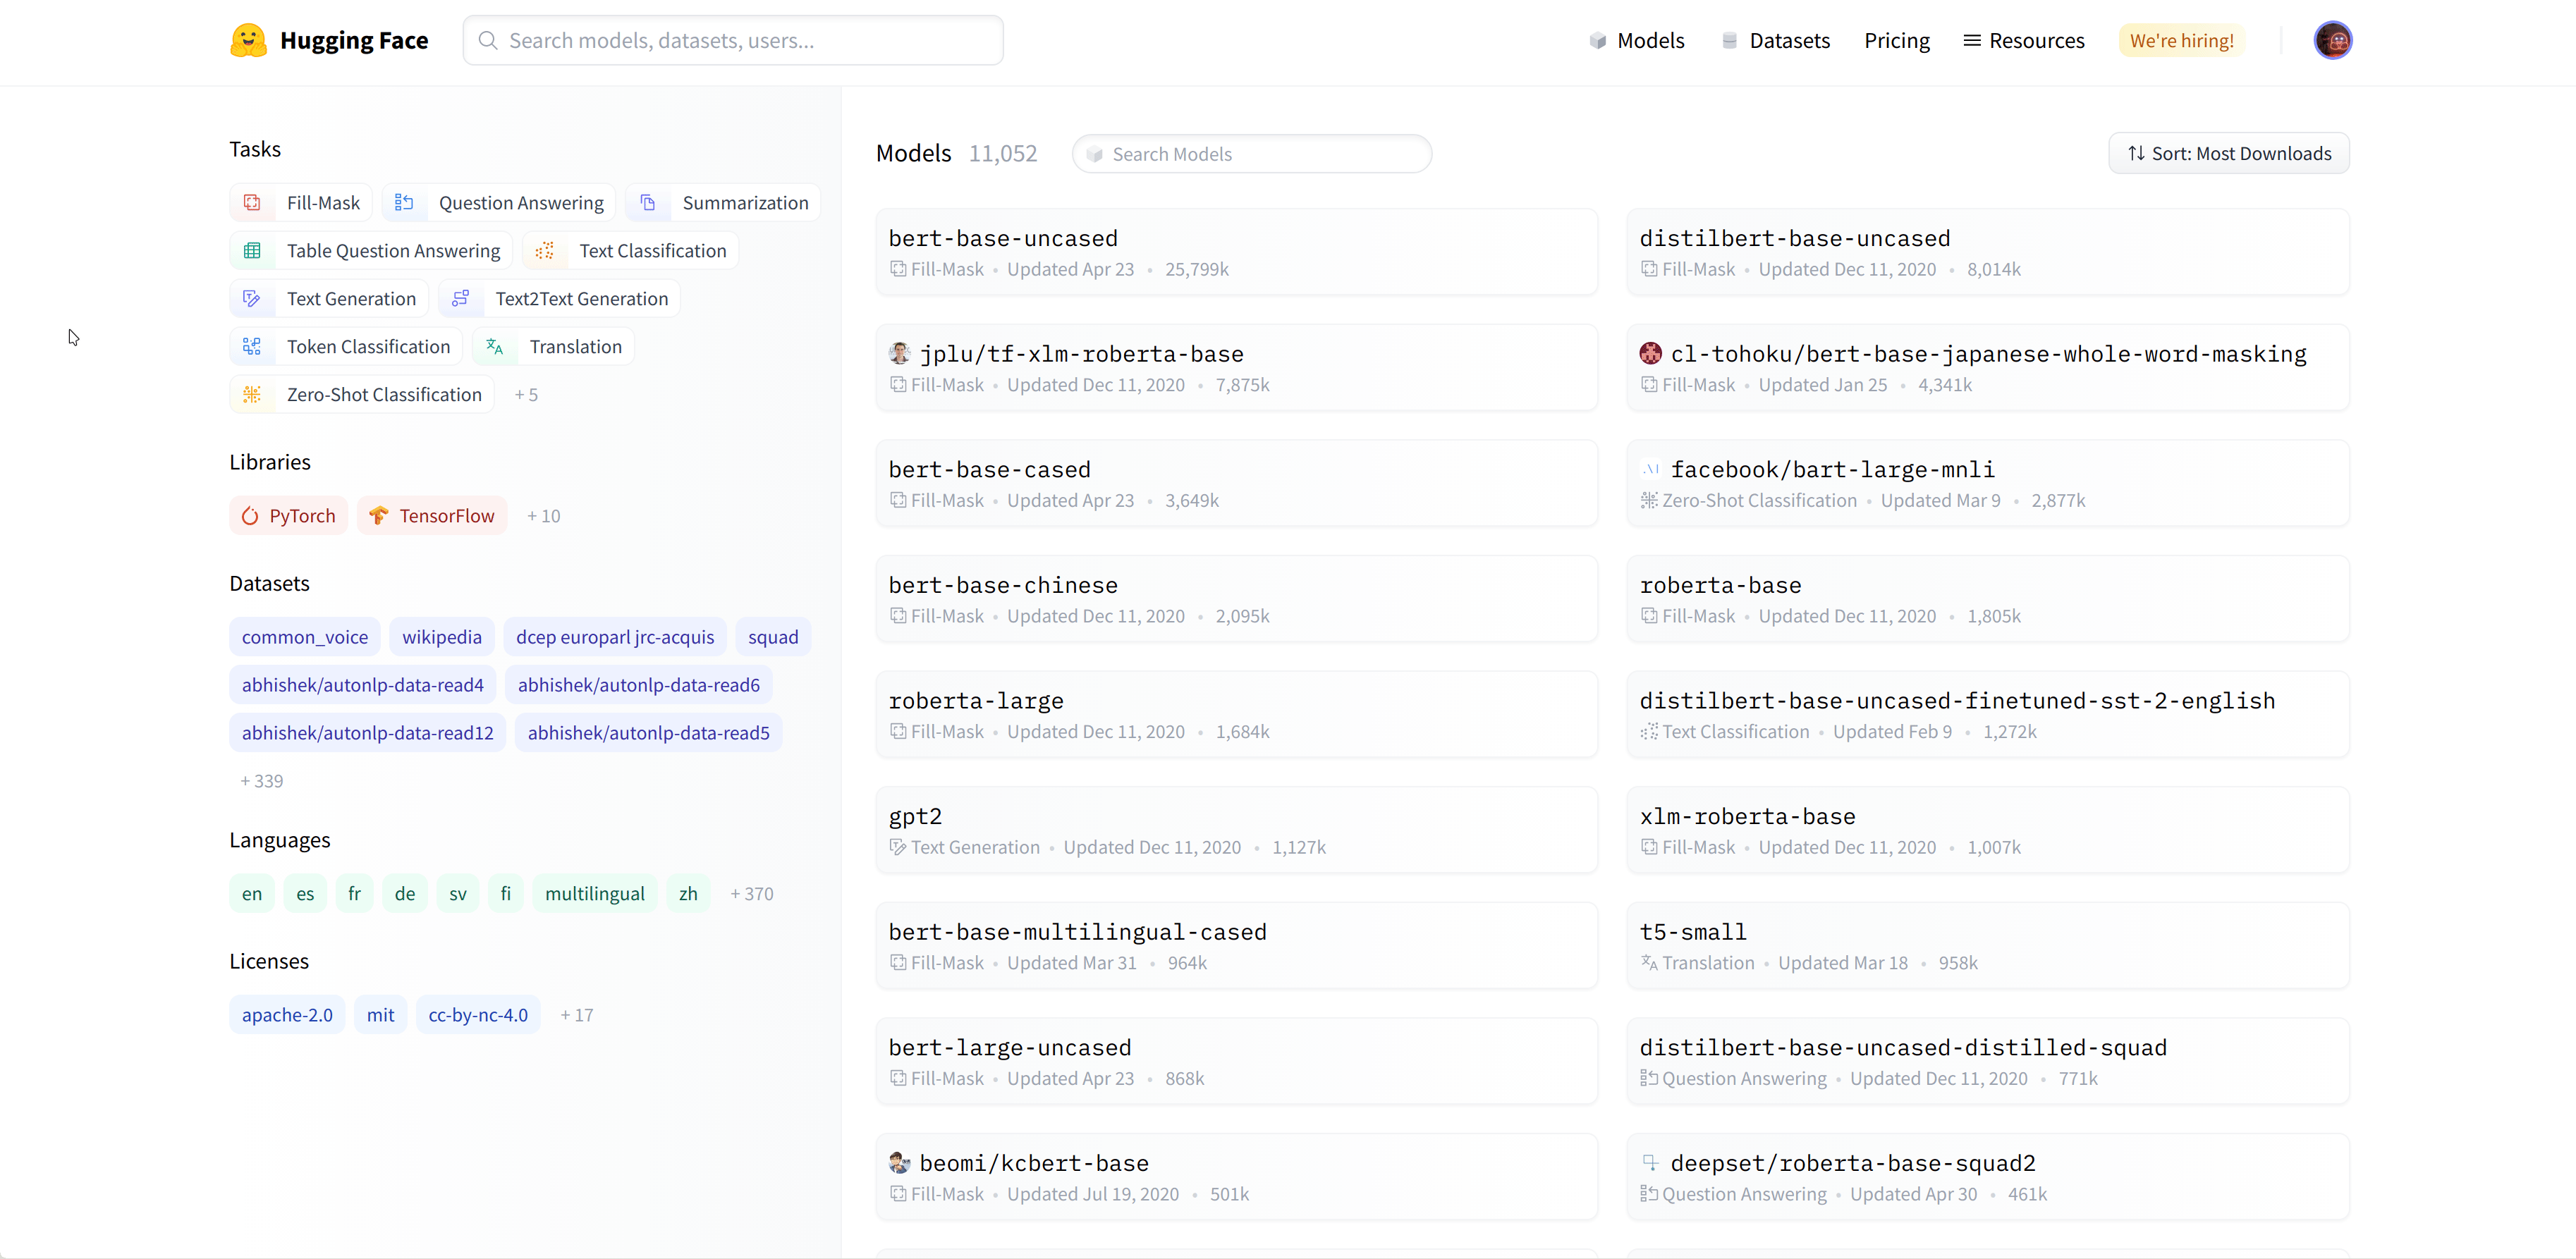

We select the `camembert-base` checkpoint to try it out. The identifier `camembert-base` is all we need to start using it! As you’ve seen in previous chapters, we can instantiate it using the `pipeline()` function:

In [4]:
from transformers import pipeline

camembert_fill_mask = pipeline("fill-mask", model="camembert-base")
results = camembert_fill_mask("Le camembert est <mask> :)")
results

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] CamembertForMaskedLM LOAD REPORT from: camembert-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'score': 0.49091655015945435,
  'token': 7200,
  'token_str': 'délicieux',
  'sequence': 'Le camembert est délicieux :)'},
 {'score': 0.10557064414024353,
  'token': 2183,
  'token_str': 'excellent',
  'sequence': 'Le camembert est excellent :)'},
 {'score': 0.03453359007835388,
  'token': 26202,
  'token_str': 'succulent',
  'sequence': 'Le camembert est succulent :)'},
 {'score': 0.03303172439336777,
  'token': 528,
  'token_str': 'meilleur',
  'sequence': 'Le camembert est meilleur :)'},
 {'score': 0.030076900497078896,
  'token': 1654,
  'token_str': 'parfait',
  'sequence': 'Le camembert est parfait :)'}]

---

As you can see, loading a model within a pipeline is extremely simple. The only thing you need to watch out for is that the chosen checkpoint is suitable for the task it’s going to be used for. For example, here we are loading the `camembert-base` checkpoint in the fill-mask pipeline, which is completely fine. But if we were to load this checkpoint in the `text-classification` pipeline, the results would not make any sense because the head of `camembert-base` is not suitable for this task! We recommend using the task selector in the Hugging Face Hub interface in order to select the appropriate checkpoints:

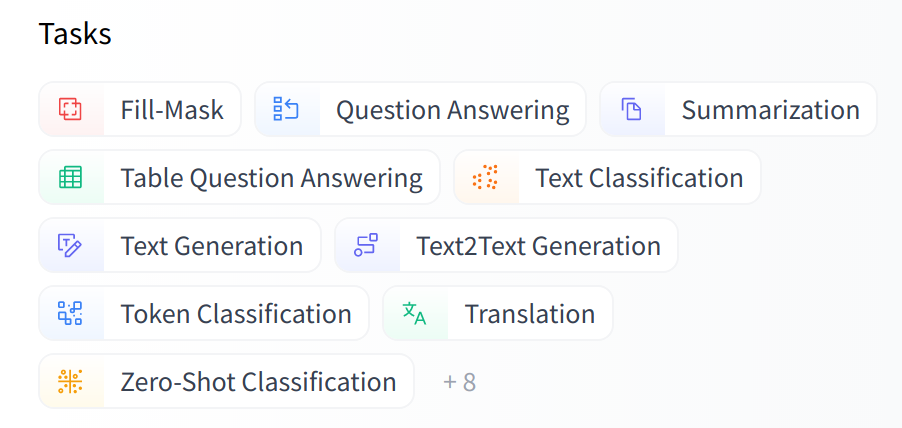

You can also instantiate the checkpoint using the model architecture directly:

In [5]:
from transformers import CamembertTokenizer, CamembertForMaskedLM

tokenizer = CamembertTokenizer.from_pretrained("camembert-base")
model = CamembertForMaskedLM.from_pretrained("camembert-base")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] CamembertForMaskedLM LOAD REPORT from: camembert-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


---

However, we recommend using the Auto* classes instead, as these are by design architecture-agnostic. While the previous code sample limits users to checkpoints loadable in the CamemBERT architecture, using the Auto* classes makes switching checkpoints simple:

In [6]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained("camembert-base")
model = AutoModelForMaskedLM.from_pretrained("camembert-base")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] CamembertForMaskedLM LOAD REPORT from: camembert-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


---

When using a pretrained model, make sure to check how it was trained, on which datasets, its limits, and its biases. All of this information should be indicated on its model card.